In [46]:
# %pip install torchvision

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim 
from torchvision import datasets, transforms 


transform = transforms.Compose([
    transforms.ToTensor(), # Bilder nach Tensor umwandeln 
])

train_dataset = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 9.59MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 264kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.46MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.8MB/s]


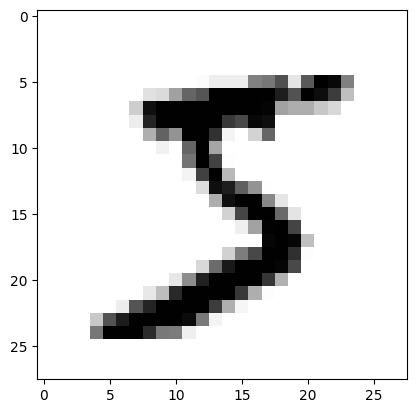

In [48]:
import matplotlib.pyplot as plt

plt.imshow(train_dataset[0][0][0], cmap="binary")

In [49]:
# Model + Verlustfunktion + Optimierer 

class NN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(28 * 28, 128 ) # 28*28 Pixel auf 128 Neuronen
        self.bn1 = nn.BatchNorm1d(128)
        self.layer2 = nn.Linear(128, 64) # Hidden Layer
        self.bn2 = nn.BatchNorm1d(64)
        self.drop = nn.Dropout(0.3) # 30 % der Aktivierung wird auf Null gesetzt 
        self.layer3 = nn.Linear(64, 10 )

    
    # def forward(self,x):
    #     x = x.view(-1, 28*28) # flatten 2D -> 1D
    #     x = torch.relu(self.bn1(self.layer1(x))) # Pre-Activation 
    #     x = torch.relu(self.bn2(self.layer2(x))) # 
    #     x = self.drop(x) # übliche Stelle 
    #     x = self.layer3(x) # logits -> Identitätsaktivierung 
    #     # Pytorch feature 
    #     return x 
    
    def forward(self,x):
        x = x.view(-1, 28*28) # flatten 2D -> 1D
        #x = self.bn1(torch.relu(self.layer1(x))) # Post-Activation 
        #x = self.bn2(torch.relu(self.layer2(x))) #
        x =  torch.relu(self.layer1(x))
        x =  torch.relu(self.layer2(x))
        x = self.drop(x) # übliche Stelle 
        x = self.layer3(x) # logits -> Identitätsaktivierung 
        # Pytorch feature 
        return x 

In [54]:
# Training 

model = NN()
lr = 1e-2
lr_adam = 1e-3
loss = nn.CrossEntropyLoss() # weil Multiklassen-Problem, CrossEntropy in Pytorch unterstützt nur logits 
optimizer = optim.SGD(model.parameters(), lr=lr)
optimizer = optim.Adam(model.parameters(), lr=lr_adam) # moderner Optimierungsverfahren 


n_epochs = 10

for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0 # Verlust pro Epoche 
    for images, labels in train_loader:
        optimizer.zero_grad() 
        outputs = model(images) # Erwartung 
        curr_loss = loss(outputs, labels) # Unterschied Erwartung/Realität 
        running_loss += curr_loss 
        # magische Zeilen
        curr_loss.backward() # Gradienten berechnen 
        optimizer.step() # Optimierungsverfahren anwenden 
    
    print(f"Epoch[{epoch+1}/{n_epochs}], Loss: {running_loss}")

Epoch[1/10], Loss: 376.3284606933594
Epoch[2/10], Loss: 156.38504028320312
Epoch[3/10], Loss: 111.59849548339844
Epoch[4/10], Loss: 87.0051040649414
Epoch[5/10], Loss: 71.55760955810547
Epoch[6/10], Loss: 59.18794250488281
Epoch[7/10], Loss: 50.53893280029297
Epoch[8/10], Loss: 43.613792419433594
Epoch[9/10], Loss: 38.096885681152344
Epoch[10/10], Loss: 33.47584533691406


In [55]:
model.eval() # Evaluierungsmodus
correct = 0
total = 0
 
with torch.no_grad(): 
    for images, labels in test_loader:
        outputs = model(images) # logits
        predicted = torch.max(outputs.data, 1)[-1] # argmax-> at which class we have maximum logit
        total += labels.size(0)
        correct += (predicted==labels).sum().item()
 
accuracy = correct/total
print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 97.76%


In [52]:
len(train_dataset)

60000

In [53]:
len(test_dataset)

10000